# Assignment 05: Logistic Regression and K-Nearest Neighbors

Logistic regression and KNN are implemented from scratch with NumPy; no built-in classifiers or optimizers are used. Datasets are the UCI Banknote Authentication and UCI Heart Disease (Cleveland) collections, fetched directly from the UCI repository.

In [1]:
import io
import urllib.request

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
np.random.seed(0)

## Datasets

The Banknote dataset has 1372 samples with four image-derived features and a binary label. The Heart Disease dataset has 303 samples with 13 clinical features and a target in 0-4; rows with missing values (encoded as `?`) are dropped and the target is binarized to disease presence (`1`) or absence (`0`). Logistic regression is trained on the raw features; KNN features are standardized because Euclidean distance is scale-sensitive.

In [2]:
BANKNOTE_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
HEART_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"


def fetch(url):
    with urllib.request.urlopen(url) as r:
        return r.read().decode()


banknote = np.loadtxt(io.StringIO(fetch(BANKNOTE_URL)), delimiter=",")
X_bank, y_bank = banknote[:, :4], banknote[:, 4].astype(int)

heart_raw = np.genfromtxt(io.StringIO(fetch(HEART_URL)), delimiter=",")
heart = heart_raw[~np.isnan(heart_raw).any(axis=1)]
X_heart, y_heart = heart[:, :13], (heart[:, 13] > 0).astype(int)

print("Banknote:", X_bank.shape, "positive:", y_bank.sum())
print("Heart  :", X_heart.shape, "positive:", y_heart.sum())

Banknote: (1372, 4) positive: 610
Heart  : (297, 13) positive: 137


In [3]:
def train_test_split(X, y, test_size=0.2, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(y))
    n_test = int(test_size * len(y))
    return X[idx[n_test:]], X[idx[:n_test]], y[idx[n_test:]], y[idx[:n_test]]


def standardize(X_train, X_test):
    mu, sigma = X_train.mean(axis=0), X_train.std(axis=0)
    return (X_train - mu) / sigma, (X_test - mu) / sigma


def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

## Logistic Regression

The model computes the logit $z = w^T x + b$ and the probability $p = \sigma(z) = (1 + e^{-z})^{-1}$; a sample is positive when $p \ge \tau$ with $\tau = 0.5$. The binary cross-entropy loss is

$$J = -\frac{1}{m}\sum_{i=1}^{m}\left[y_i\log p_i + (1-y_i)\log(1-p_i)\right].$$

In [4]:
class LogisticRegression:
    def __init__(self, lr=0.1, n_iter=2000):
        self.lr = lr
        self.n_iter = n_iter
        self.w = None
        self.b = 0.0
        self.losses = []

    @staticmethod
    def sigmoid(z):
        return np.where(z >= 0, 1.0 / (1.0 + np.exp(-z)), np.exp(z) / (1.0 + np.exp(z)))

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0.0
        self.losses = []
        for _ in range(self.n_iter):
            z = X @ self.w + self.b
            p = self.sigmoid(z)
            with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
                self.losses.append(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))
            grad_w = (X.T @ (p - y)) / m
            grad_b = np.sum(p - y) / m
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b
        return self

    def predict_proba(self, X):
        return self.sigmoid(X @ self.w + self.b)

    def predict(self, X, tau=0.5):
        return (self.predict_proba(X) >= tau).astype(int)

In [5]:
X_tr, X_te, y_tr, y_te = train_test_split(X_bank, y_bank)

model = LogisticRegression(lr=0.1, n_iter=2000).fit(X_tr, y_tr)


def bce(y, p):
    with np.errstate(divide="ignore", invalid="ignore"):
        return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


p_tr = model.predict_proba(X_tr)
p_te = model.predict_proba(X_te)
print(f"Training loss: {bce(y_tr, p_tr):.6f}")
print(f"Test loss    : {bce(y_te, p_te):.6f}")
print(f"Test accuracy: {100 * accuracy(y_te, model.predict(X_te)):.2f}%")

Training loss: 0.029155
Test loss    : 0.031122
Test accuracy: 98.91%


## Gradient Descent

The gradient of $J$ follows from the chain rule. With $p_i = \sigma(z_i)$ and $\sigma'(z) = \sigma(z)(1-\sigma(z))$:

$$\frac{\partial J}{\partial p_i} = -\frac{1}{m}\left(\frac{y_i}{p_i}-\frac{1-y_i}{1-p_i}\right) = \frac{p_i - y_i}{m\,p_i(1-p_i)}.$$

Multiplying by $\partial p_i / \partial z_i = p_i(1-p_i)$ gives $\partial J/\partial z_i = (p_i - y_i)/m$. Since $\partial z_i/\partial w_j = x_{ij}$ and $\partial z_i/\partial b = 1$,

$$\frac{\partial J}{\partial w} = \frac{1}{m}X^T(p-y), \qquad \frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}(p_i - y_i).$$

Batch gradient descent updates $w \leftarrow w - \alpha\,\partial J/\partial w$ and $b \leftarrow b - \alpha\,\partial J/\partial b$ over the full training set each iteration.

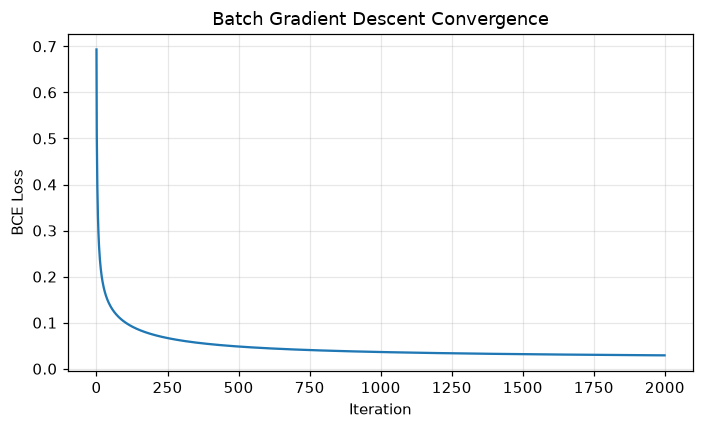

In [6]:
plt.figure(figsize=(6.5, 4))
plt.plot(model.losses, lw=1.5)
plt.xlabel("Iteration")
plt.ylabel("BCE Loss")
plt.title("Batch Gradient Descent Convergence")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Learning-Rate Analysis

The model is retrained with $\alpha \in \{10^{-4}, 10^{-3}, 10^{-2}, 10^{-1}, 1, 10\}$ and the loss curves are compared on a logarithmic scale. Non-finite losses (from $\log 0$) are capped for display.

alpha = 0.0001: final loss = 0.455850297025495
alpha = 0.001: final loss = 0.19689304329719648


alpha = 0.01: final loss = 0.07415221332620828
alpha = 0.1: final loss = 0.029159151156424926


alpha = 1: final loss = 0.01949812131311187
alpha = 10: final loss = non-finite (diverged)


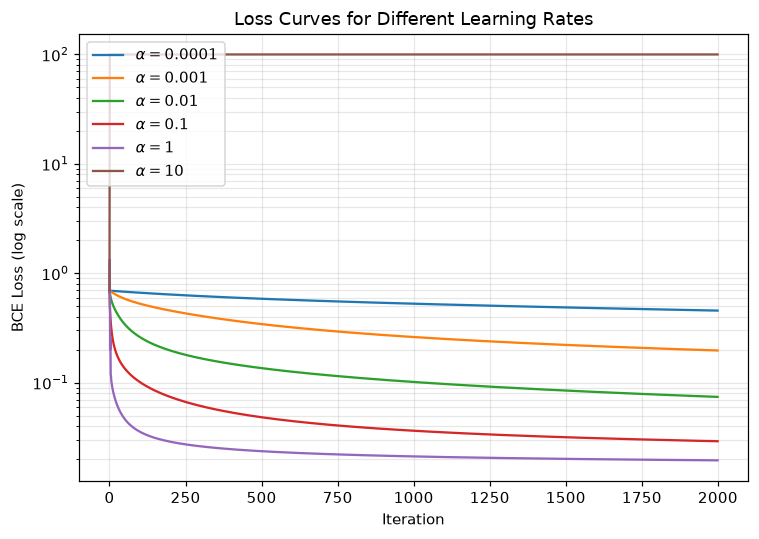

In [7]:
rates = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0]
CAP = 1e2

plt.figure(figsize=(7, 5))
for alpha in rates:
    m = LogisticRegression(lr=alpha, n_iter=2000).fit(X_tr, y_tr)
    L = np.array(m.losses)
    final = L[-1]
    print(f"alpha = {alpha:g}: final loss = {final if np.isfinite(final) else 'non-finite (diverged)'}")
    plt.semilogy(np.nan_to_num(L, nan=CAP, posinf=CAP, neginf=CAP), lw=1.5, label=rf"$\alpha = {alpha:g}$")

plt.xlabel("Iteration")
plt.ylabel("BCE Loss (log scale)")
plt.title("Loss Curves for Different Learning Rates")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

Rates $10^{-4}$ and $10^{-3}$ converge slowly, still far from the minimum after 2000 iterations; $10^{-2}$ and $10^{-1}$ converge stably; $\alpha = 1$ overshoots, its loss rising above the initial value before descending, marking the onset of instability; $\alpha = 10$ diverges, the loss becoming non-finite within a single step because $\log 0 \to -\infty$. Overshooting happens when the step exceeds the curvature of the loss surface, so the update skips past the minimum and, for large enough steps, grows without bound.

## K-Nearest Neighbors

For a test point $x$, KNN ranks training points by Euclidean distance $d(x, x_i) = \sqrt{\sum_j (x_j - x_{ij})^2}$ and assigns the majority label among the $k$ nearest neighbors.

In [8]:
def knn_predict(X_train, y_train, X_test, k):
    preds = np.empty(len(X_test), dtype=int)
    for i, x in enumerate(X_test):
        d = np.sqrt(((X_train - x) ** 2).sum(axis=1))
        nn = np.argsort(d)[:k]
        preds[i] = np.argmax(np.bincount(y_train[nn]))
    return preds

In [9]:
X_tr, X_te, y_tr, y_te = train_test_split(X_heart, y_heart)
X_tr_s, X_te_s = standardize(X_tr, X_te)

ks = [1, 3, 5, 7, 9, 15]
accs = {}
for k in ks:
    accs[k] = accuracy(y_te, knn_predict(X_tr_s, y_tr, X_te_s, k))
    print(f"k = {k:2d}: accuracy = {100 * accs[k]:.2f}%")

best_k = max(accs, key=accs.get)
print(f"Best k = {best_k} with {100 * accs[best_k]:.2f}% accuracy")

k =  1: accuracy = 71.19%
k =  3: accuracy = 77.97%
k =  5: accuracy = 74.58%
k =  7: accuracy = 76.27%
k =  9: accuracy = 77.97%
k = 15: accuracy = 79.66%
Best k = 15 with 79.66% accuracy


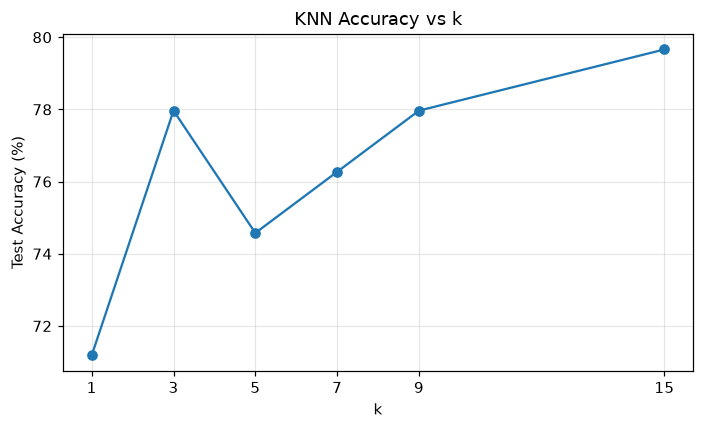

In [10]:
plt.figure(figsize=(6.5, 4))
plt.plot(list(accs), [100 * accs[k] for k in accs], "o-", lw=1.5)
plt.xlabel("k")
plt.ylabel("Test Accuracy (%)")
plt.title("KNN Accuracy vs k")
plt.xticks(ks)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

$k=1$ gives the lowest accuracy because a single neighbor overfits noise and outliers. Accuracy improves with $k$ and peaks at $k=15$ on this split, since averaging more neighbors suppresses variance on a small, noisy dataset. In general, very small $k$ overfits while very large $k$ over-smooths and eventually underfits; here the optimum is the largest tested value, so larger $k$ could be probed before accuracy is expected to decline.

## Nonlinear Decision Boundary

2000 samples are drawn with $x_1, x_2 \sim U(-2, 2)$ and $y = 1$ when $x_1^2 + x_2^2 > 2$, otherwise $y = 0$. The true boundary is circular, so a linear rule cannot separate the classes. Three models are compared: logistic regression on $[x_1, x_2]$, logistic regression on the quadratic features $[x_1, x_2, x_1^2, x_2^2, x_1 x_2]$, and KNN on $[x_1, x_2]$.

In [11]:
rng = np.random.default_rng(0)
n = 2000
X = rng.uniform(-2, 2, size=(n, 2))
y = (X[:, 0] ** 2 + X[:, 1] ** 2 > 2).astype(int)
X_tr, X_te, y_tr, y_te = train_test_split(X, y)


def quadratic(g):
    return np.c_[g[:, 0], g[:, 1], g[:, 0] ** 2, g[:, 1] ** 2, g[:, 0] * g[:, 1]]


lr_linear = LogisticRegression(lr=0.1, n_iter=5000).fit(X_tr, y_tr)
lr_quad = LogisticRegression(lr=0.1, n_iter=5000).fit(quadratic(X_tr), y_tr)
KNN_K = 15

print(f"LR on [x1, x2]                  : {100 * accuracy(y_te, lr_linear.predict(X_te)):.2f}%")
print(f"LR on quadratic features        : {100 * accuracy(y_te, lr_quad.predict(quadratic(X_te))):.2f}%")
print(f"KNN (k={KNN_K}) on [x1, x2]     : {100 * accuracy(y_te, knn_predict(X_tr, y_tr, X_te, KNN_K)):.2f}%")

LR on [x1, x2]                  : 61.25%
LR on quadratic features        : 99.75%
KNN (k=15) on [x1, x2]     : 97.50%


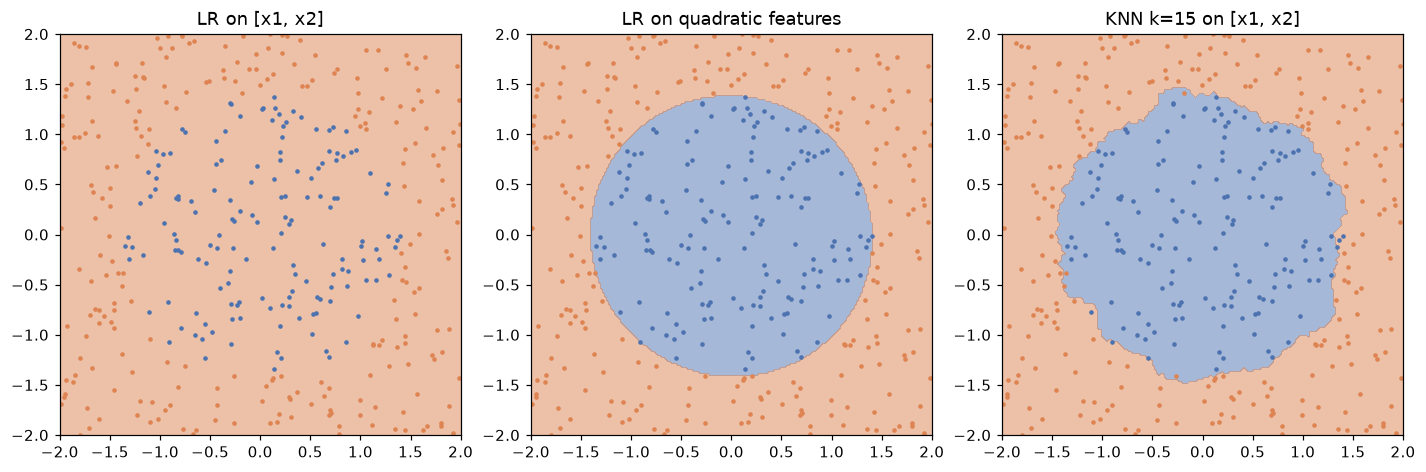

In [12]:
def plot_boundary(ax, pred_fn, title):
    xs = np.linspace(-2, 2, 200)
    xx, yy = np.meshgrid(xs, xs)
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = pred_fn(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], colors=["#4c72b0", "#dd8452"], alpha=0.5)
    ax.scatter(X_te[y_te == 0, 0], X_te[y_te == 0, 1], c="#4c72b0", s=4)
    ax.scatter(X_te[y_te == 1, 0], X_te[y_te == 1, 1], c="#dd8452", s=4)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_aspect("equal")
    ax.set_title(title)


fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
plot_boundary(axes[0], lambda g: lr_linear.predict(g), "LR on [x1, x2]")
plot_boundary(axes[1], lambda g: lr_quad.predict(quadratic(g)), "LR on quadratic features")
plot_boundary(axes[2], lambda g: knn_predict(X_tr, y_tr, g, KNN_K), f"KNN k={KNN_K} on [x1, x2]")
plt.tight_layout()
plt.show()

Standard logistic regression fails because its decision surface is a single hyperplane, which cannot follow the circular boundary. Adding quadratic features lifts the data into a space where the circle $x_1^2 + x_2^2 = 2$ becomes linear, so the same model then separates the classes almost perfectly. KNN needs no explicit transform: it uses local distance structure, so it traces the nonlinear boundary directly from the training points.